# `cool_maps` Feature Demonstration
This notebook demonstrates the capabilities of the `cool_maps` toolbox, highlighting the dual mapping engines, high-speed data fetching with local caching, and robust, vectorized utilities.

In [1]:
import cool_maps.plot as cplt
import cool_maps.download as cdown
import matplotlib.pyplot as plt
import numpy as np
# Define a bounding box (Mid-Atlantic Bight)
extent = [-76.0, -71.0, 38.0, 41.5]

# Come up with a nice tick spacing for that exte
ticks = np.arange(-76)

## 1. Dual Mapping Engines
`cool_maps` supports both `cartopy` (default) and `basemap`. You can easily switch engines globally, and the toolbox abstracts away the underlying API differences, allowing you to use a single syntax (like `proj='mercator'`).

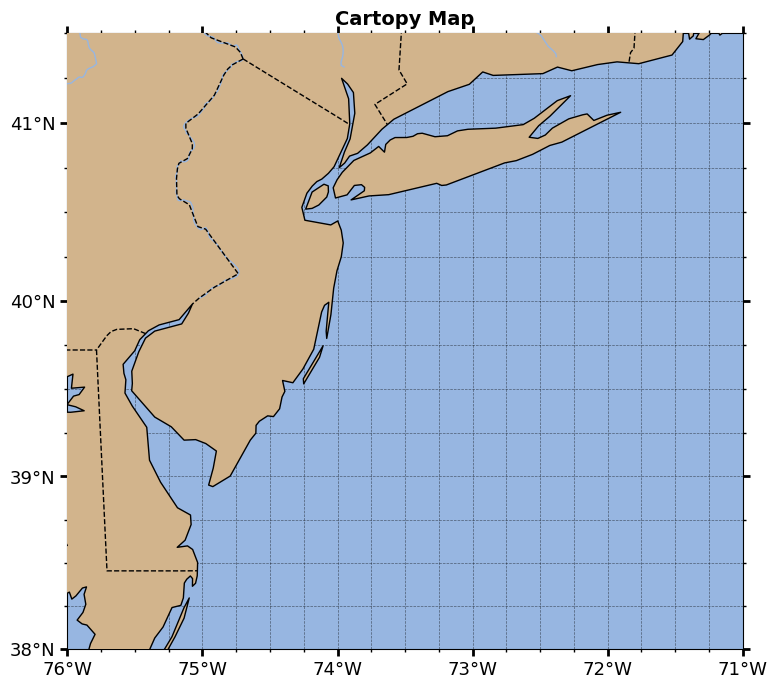

In [2]:
# Cartopy Map (Default Engine)
cplt.set_engine('cartopy')

fig, ax = cplt.create(
    extent, 
    proj='mercator', 
    coast='mid',
    title='Cartopy Map',
    gridlines=True,
    ticks=True
)


plt.show()

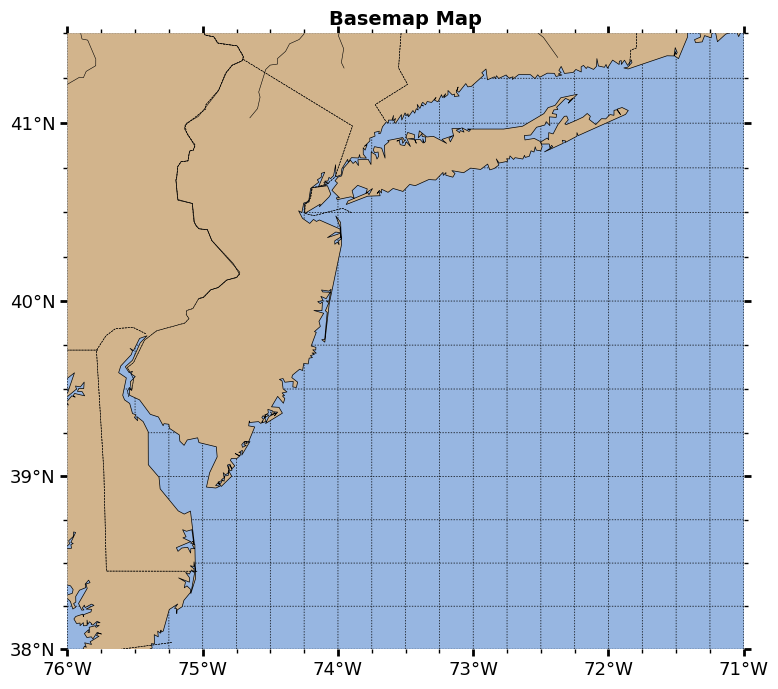

In [3]:
# Basemap Map
cplt.set_engine('basemap')

fig, ax = cplt.create(
    extent, 
    proj='mercator', 
    coast='mid',
    title='Basemap Map',
    gridlines=True,
    ticks=True
)
plt.show()

## 2. Bathymetry Download with Caching
The `get_bathymetry` function now features local caching. The first time you run this cell, it will download data from the THREDDS server. Subsequent runs will instantly load the NetCDF data from your local cache (`~/.cache/cool_maps/`), drastically reducing plot generation time.

For large extents, `get_bathymetry` automatically splits the request into 10-degree tiles before hitting
the server (the THREDDS server rejects single OpenDAP requests that are too large) and stitches the
results back together -- each tile is cached individually. Pass `chunk_size=` (degrees) to change the
tile size, or `chunk_size=None` to disable tiling entirely.

In [4]:
%%time
# Fetch bathymetry (caches locally for fast subsequent loads)
bathy = cdown.get_bathymetry(extent=extent, use_cache=True)
display(bathy)

<xarray.Dataset> Size: 2MB
Dimensions:    (latitude: 840, longitude: 1200)
Coordinates:
  * latitude   (latitude) float64 7kB 38.0 38.01 38.01 ... 41.49 41.49 41.5
  * longitude  (longitude) float64 10kB -76.0 -75.99 -75.99 ... -71.01 -71.0
Data variables:
    z          (latitude, longitude) int16 2MB ...
Attributes:
    Conventions:  CF-1.6
    title:        The GEBCO_2020 Grid - a continuous terrain model for oceans...
    institution:  On behalf of the General Bathymetric Chart of the Oceans (G...
    source:       The GEBCO_2020 Grid is the latest global bathymetric produc...
    history:      Information on the development of the data set and the sour...
    references:   DOI: 10.5285/836f016a-33be-6ddc-e053-6c86abc0788e
    comment:      The data in the GEBCO_2020 Grid should not be used for navi...
    node_offset:  1.0

CPU times: user 24.1 ms, sys: 8.86 ms, total: 32.9 ms
Wall time: 35.3 ms


## 3. Plotting Bathymetry
Using the `add_bathymetry` method, we can effortlessly visualize the downloaded bathymetry data on the map using various styles (like `shadedcontour`, `blues`, or `topo`).

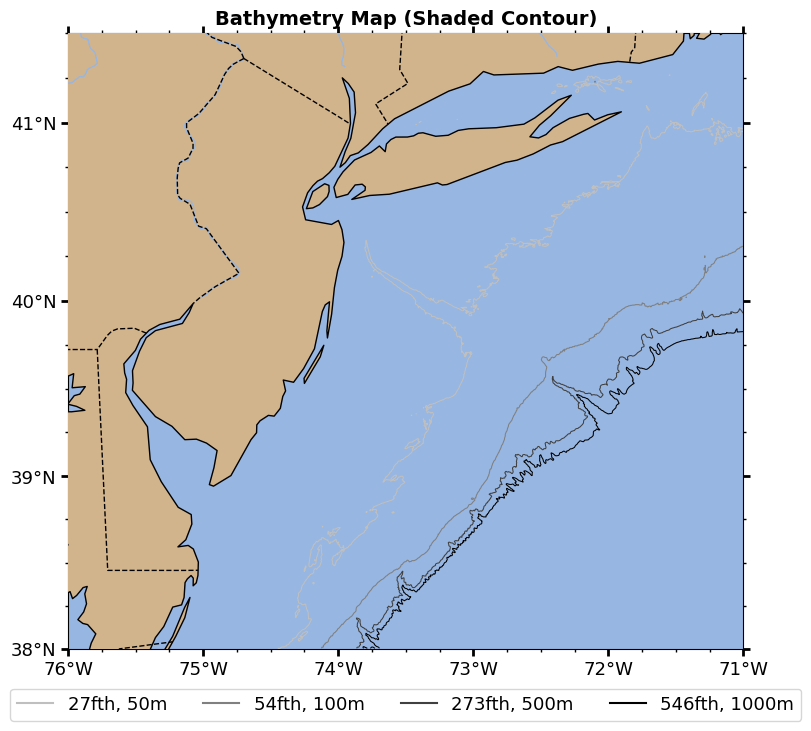

In [5]:
cplt.set_engine('cartopy')
fig, ax = cplt.create(extent, proj='mercator', title='Bathymetry Map (Shaded Contour)', coast='mid')

bargs = {
    "levels": [-1000, -500, -100, -50],
    "method": "shadedcontour",
    "legend_scale": "both",
}

cplt.add_bathymetry(
    ax,
    bathy['longitude'].data,
    bathy['latitude'].data,
    bathy['z'].data,
    **bargs
)
plt.show()

## 4. High-Speed Vectorized Glider Data
The `get_glider_bathymetry` function downloads data via ERDDAP and performs derivative-based spike-removal. Thanks to Pandas vectorization, processing the derivatives is lightning fast, and Type Hints ensure safety.

In [6]:
%%time
# Example glider deployment
deployment = 'ru33-20200715T1527'
try:
    glider_data = cdown.get_glider_bathymetry(deployment)
    display(glider_data.head())
except Exception as e:
    print(f"Could not fetch glider data: {e}")

Could not fetch glider data: Unable to access deployment ru33-20200715T1527. Error: HTTP Error 404: 
CPU times: user 9.86 ms, sys: 3.66 ms, total: 13.5 ms
Wall time: 2.87 s
